In [10]:
import os
import re
import pygmt
from io import StringIO
import numpy as np
import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def GNSSTimeSeries2Pandas(stat,analysisCenter='ovsi'):
    filename = os.path.join(datadir, f"{stat}.ovs.final_igb14.pos")
    with open(filename, 'r') as f:
        lines = f.readlines()

        data_lines = [line for line in lines if re.match(r'^\s*\d{8}\s+\d{6}', line)]

        df = pd.read_csv(StringIO("".join(data_lines)), sep=r'\s+', header=None,
                        names=[
                        'YYYYMMDD','HHMMSS','JJJJJ.JJJJ','X','Y','Z',
                        'Sx','Sy','Sz','Rxy','Rxz','Ryz',
                        'NLat','Elong','Height',
                        'dN','dE','dU','Sn','Se','Su',
                        'Rne','Rnu','Reu','Soln'
                    ])
        df['Date'] = pd.to_datetime(df['YYYYMMDD'].astype(str), format='%Y%m%d', errors='coerce')
        df['NumDate'] = df['Date'].apply(lambda x: x.year + (x.dayofyear - 1)/365.25)
        print(df[['Date', 'NumDate']].head())

        #rename for better understanding
        df['Npos'] = df['dN']
        df['Epos'] = df['dE']
        df['Upos'] = df['dU']
        df['Nerr'] = df['Sn']
        df['Eerr'] = df['Se']
        df['Uerr'] = df['Su']

        # add station name as a column
        df['STAT'] = stat

    return df


datadir = "/Users/nchavarria6/Library/CloudStorage/OneDrive-Personal/CODING/GNSS.processing/POS-FILES_1days-sol"
df = GNSSTimeSeries2Pandas('LAFE')
print(df)
 

        Date      NumDate
0 2009-07-06  2009.509240
1 2009-07-07  2009.511978
2 2009-07-08  2009.514716
3 2009-07-09  2009.517454
4 2009-07-10  2009.520192
      YYYYMMDD  HHMMSS  JJJJJ.JJJJ             X             Y             Z  \
0     20090706  115900  55018.4993  552167.18802 -6.261308e+06  1.079237e+06   
1     20090707  115900  55019.4993  552167.18981 -6.261308e+06  1.079237e+06   
2     20090708  115900  55020.4993  552167.18853 -6.261308e+06  1.079237e+06   
3     20090709  115900  55021.4993  552167.18803 -6.261308e+06  1.079237e+06   
4     20090710  115900  55022.4993  552167.18665 -6.261308e+06  1.079237e+06   
...        ...     ...         ...           ...           ...           ...   
5398  20250917  115900  60935.4993  552167.00867 -6.261308e+06  1.079237e+06   
5399  20250918  115900  60936.4993  552167.00379 -6.261308e+06  1.079237e+06   
5400  20250919  115900  60937.4993  552167.01292 -6.261308e+06  1.079237e+06   
5401  20250920  115900  60938.4993  552167.0

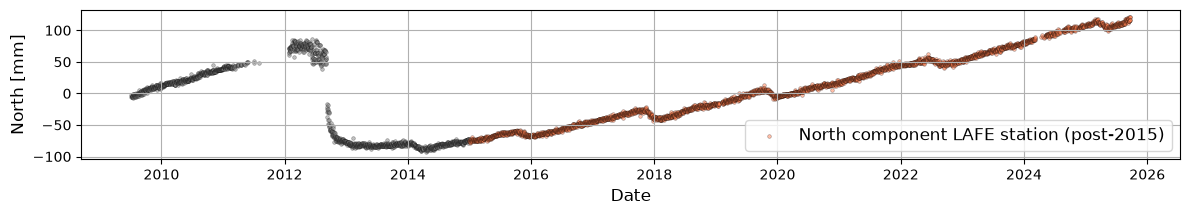

In [12]:
before_2015 = df['Date'] < '2015-01-01'
after_2015 = df['Date'] >= '2015-01-01'

plt.figure(figsize=(12, 6))

ax1 = plt.subplot(3, 1, 1)
ax1.scatter(df.loc[before_2015, 'Date'], df.loc[before_2015, 'Npos'] * 1000,
            #label='North component LAFE station',
            color='grey', linewidth=0.3, s=7, alpha=0.5, edgecolors='black')

ax1.scatter(df.loc[after_2015, 'Date'], df.loc[after_2015, 'Npos'] * 1000,
            label='North component LAFE station (post-2015)',
            color='coral', linewidth=0.3, s=7, alpha=0.5, edgecolors='black')

ax1.set_ylabel('North [mm]', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
# Esquina inferior derecha del eje
ax1.legend(loc='lower right', fontsize=12)  # o loc='lower right', bbox_to_anchor=(1, 0))
ax1.grid(True)

#
# ax2 = plt.subplot(3, 1, 2); ax3 = plt.subplot(3, 1, 3)

plt.tight_layout()
plt.savefig("lafe_raw_gnss_time_series.png", bbox_inches='tight', dpi=700)


